In [ ]:
#author: Avery
#create bubble plot for metatranscriptomic samples

In [1]:
#import all dependencies
import matplotlib.pyplot as plt
import pandas as pd
from numpy import arange
from numpy.random import random
from numpy import sqrt, power
import argparse

In [ ]:
#use ../envs/bubble-plots.yaml to pip install openpyxl, a dependency

In [5]:
#read excel file to extract data. I did it this way (instead of a csv) because the authors have 
#code on their github to make the bubble plots that requires data to be in an excel file, 
#and at first I tried to follow it, but it was literally impossible to reproduce. 
data = pd.read_excel("../output/data_processing/calculations_for_bubble_plots.xlsx", "MT_bubble_plot")
print(data)

    x-axis (samples)  y-axis (genes)  size multiplier color
0                  1              24         0.000231  aqua
1                  1              23         0.000393  aqua
2                  1              22         0.000182  aqua
3                  1              21         0.000549  aqua
4                  1              20         0.000333  aqua
..               ...             ...              ...   ...
91                 4               5         0.000017  gold
92                 4               4         0.000282  gold
93                 4               3         0.000221   red
94                 4               2         0.000287   red
95                 4               1         0.000017   red

[96 rows x 4 columns]


In [6]:
#list of genes used, which will correspond to y-axis (genes) column in data
genes = ['ech hydrogenase (echABCE)', 'energy-converting hydrogenase A (ehaBCEGNOP)', 'energy-converting hydrogenase B (ehbAHFIJKLNO)', 'coenzyme F420 hydrogenase (frhABDG)', 'hydrogenase (hyaABC/hybO/hybC)', '[NiFe] hydrogenase (hydAB)', 'methane/ammonia monooxygenase (pmoA-amoA)', 'methyl-coenzyme M reductase (mcrABCDG)', 'nitrous-oxide reductase (nosZ)', 'nitrite reductase (NO-forming)/hydroxylamine reductase (nirKS)', 'nitric oxide reductase (norB)', 'nitrite reductase (cytochrome c-552) (nrfA)', 'cytochrome c oxidase (coxABCD/AC/ctaF)', 'cytochrome c oxidase cbb3-type (ccoNOPQ_NO)', 'carbon-monoxide dehydrogenase (cooCFS/acsA)', 'ATP-citrate lyase (aclAB)', 'fumarate reductase (frdAB)', '2-oxoglutarate/2-oxoacid ferredoxin oxidoreductase (korABCD/oorABCD)', 'sulfite reductase (dsrAB)', 'sulfate adenylyltransferase (sat/met3)', 'sulfur-oxidizing protein Sox (soxABCXYZ)', 'sulfide:quinone oxidoreductase (sqr)', 'iron transport protein (FeoB/C)', 'iron transport protein (FeoA)']
genes.reverse() #reverse the genes order so that they show up in the correct order on the plot alphabetically
#list of samples for the x-axis label
samples = ['Hot Chimlet', 'Shrimp Canyon', 'X-19 at BV #4', 'Shrimp Gulley #2']

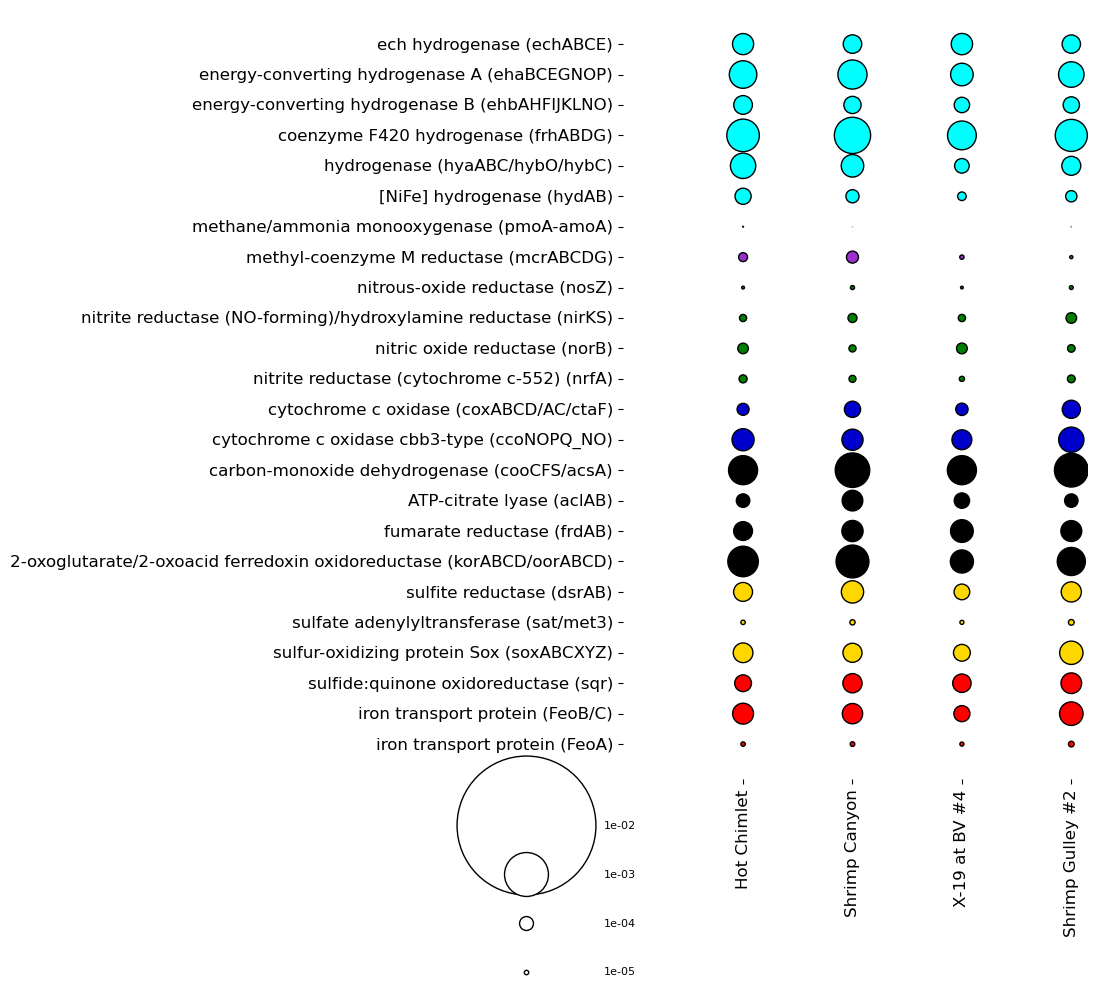

In [38]:
fig = plt.figure(figsize=(6,10)) #messed with the dimensions to make the plot taller
#Set number of xticks/yticks and remove frame
ax = fig.add_subplot(1,1,1, xticks = arange(1,len(samples)+1),
yticks = arange(1,len(genes)+1), frame_on = False)
#set the ticklabels, font size, and orientation
ax.set_xticklabels(samples, fontsize=12, rotation=90)
ax.set_yticklabels(genes, fontsize = 12, va ='center')

#Add outlines to bubbles and plot the data
# Third variable is size of the bubble, fifth creates black outlines
plt.scatter(data['x-axis (samples)'],data['y-axis (genes)'],
s=data['size multiplier']*1000000, c=data['color'], edgecolors = 'k')

#Make a legend
axes = plt.gca()

#with nums, specify the size of the legend bubbles.
#with labels, specify the label used for the legend bubbles.
nums = [10,100,1000,10000]
labels = ('1e-02', '1e-03', '1e-04', '1e-05')
#position the legend
y_lim = 0.1
axes.set_xlim(left = -0.1)

#using the variables set above, actually make the legend
La = plt.scatter([], [], s=nums[0], color = 'w', edgecolor='k')
Lb = plt.scatter([], [], s=nums[1], color = 'w', edgecolor='k')
Lc = plt.scatter([], [], s=nums[2], color = 'w', edgecolor='k')
Ld = plt.scatter([], [], s=nums[3], color = 'w', edgecolor='k')

ax.legend((Ld,Lc,Lb,La), labels , scatterpoints = 1,
loc = 'upper right', numpoints = 4, labelspacing = 3.5,
bbox_to_anchor=(0.05, -0.04), ncol = 1, fontsize = 8, handletextpad = 6, frameon = False)

#save to output pdf file
plt.savefig('MT_bubble_plot.pdf')